## FinSight AI — Day 4
### RL Environment Design with Custom Gymnasium TradingEnv

Author: Suman Das | PNB 11 yrs | MTech IAR Jadavpur University|
Asset: Reliance Industries (2019-2024)
Environment: Custom Gymnasium — State/Action/Reward design

## Cell 1 — Environment Setup + GPU Verification

In [ ]:
# ── Permanent Environment Setup ──────────────────────────
import subprocess
import sys

subprocess.run([sys.executable, "-m", "pip", "install",
                "yfinance",
                "pandas_ta",
                "gymnasium",
                "stable-baselines3[extra]",
                "--quiet"], check=True)

import os
os.kill(os.getpid(), 9)

In [6]:
# ── Verify GPU + All Libraries ────────────────────────────

import torch
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_ta as ta
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
import warnings
warnings.filterwarnings('ignore')

# ── GPU Check ─────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("=" * 45)
print("ENVIRONMENT VERIFIED")
print("=" * 45)
print(f"Device          : {device}")
if torch.cuda.is_available():
    print(f"GPU Name        : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("GPU             : Not available — using CPU")
print(f"PyTorch         : {torch.__version__} ✓")
print(f"Gymnasium       : {gym.__version__} ✓")
print(f"Stable-baselines: ✓")
print("=" * 45)
print("Ready to build RL Environment! 🚀")

ENVIRONMENT VERIFIED
Device          : cuda
GPU Name        : Tesla T4
GPU Memory      : 15.6 GB
PyTorch         : 2.10.0+cu128 ✓
Gymnasium       : 1.2.3 ✓
Stable-baselines: ✓
Ready to build RL Environment! 🚀


## Cell 2 — Data Pipeline + Walk-Forward Split

In [7]:
# ── Download and Prepare Data ─────────────────────────────
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_ta as ta
import warnings
warnings.filterwarnings('ignore')

def download_and_feature_engineer(ticker, name,
                                   start="2019-01-01",
                                   end="2024-12-31"):
    df = yf.download(ticker, start=start,
                     end=end, progress=False)

    feat = pd.DataFrame(index=df.index)
    feat['Close']        = df['Close'].squeeze()
    feat['Log_Return']   = np.log(feat['Close'] /
                                  feat['Close'].shift(1))
    feat['Volume_Ratio'] = (df['Volume'].squeeze() /
                            df['Volume'].squeeze().rolling(20).mean())
    feat['RSI']          = ta.rsi(feat['Close'], length=14)

    macd_df = ta.macd(feat['Close'])
    if macd_df is not None:
        feat['MACD'] = macd_df.iloc[:, 0]

    bb_df = ta.bbands(feat['Close'], length=20)
    if bb_df is not None:
        feat['BB_upper'] = bb_df.iloc[:, 2]
        feat['BB_lower'] = bb_df.iloc[:, 0]

    feat = feat.dropna()
    feat = feat.replace([np.inf, -np.inf], np.nan)
    feat = feat.dropna()

    return feat

# Download Reliance
df_reliance = download_and_feature_engineer(
    "RELIANCE.NS", "Reliance")

# Walk-forward split
train_df = df_reliance[df_reliance.index.year <= 2022]
test_df  = df_reliance[df_reliance.index.year == 2024]

print("=" * 45)
print("DATA READY FOR RL ENVIRONMENT")
print("=" * 45)
print(f"Features        : {df_reliance.columns.tolist()}")
print(f"Train rows      : {len(train_df)} (2019-2022)")
print(f"Test rows       : {len(test_df)}  (2024)")
print(f"Features count  : {len(df_reliance.columns)}")
print("\n✓ Data pipeline ready!")

DATA READY FOR RL ENVIRONMENT
Features        : ['Close', 'Log_Return', 'Volume_Ratio', 'RSI', 'MACD', 'BB_upper', 'BB_lower']
Train rows      : 965 (2019-2022)
Test rows       : 245  (2024)
Features count  : 7

✓ Data pipeline ready!


## Cell 3 — Build the Trading Environment

In [8]:
import gymnasium as gym
from gymnasium import spaces

class TradingEnvironment(gym.Env):
    """
    Custom Trading Environment for Reliance Industries.

    STATE  : 30 days of market data + portfolio info
    ACTION : 0=Hold, 1=Buy, 2=Sell
    REWARD : Sharpe-adjusted daily return
    """

    def __init__(self, df, lookback=30,
                 starting_cash=10000,
                 transaction_cost=0.001,
                 stop_loss=0.70):
        super(TradingEnvironment, self).__init__()

        # ── Data ──────────────────────────────────────
        self.df               = df.reset_index(drop=True)
        self.feature_cols     = ['Log_Return', 'Volume_Ratio',
                                  'RSI', 'MACD',
                                  'BB_upper', 'BB_lower']
        self.n_features       = len(self.feature_cols)

        # ── Parameters ────────────────────────────────
        self.lookback         = lookback
        self.starting_cash    = starting_cash
        self.transaction_cost = transaction_cost
        self.stop_loss        = stop_loss

        # ── Action Space: 0=Hold, 1=Buy, 2=Sell ───────
        self.action_space = spaces.Discrete(3)

        # ── Observation Space ─────────────────────────
        # 30 days × 6 features + 2 portfolio values
        # = 182 values the agent sees at each step
        obs_size = self.lookback * self.n_features + 2
        self.observation_space = spaces.Box(
            low   = -np.inf,
            high  =  np.inf,
            shape = (obs_size,),
            dtype = np.float32
        )

    def reset(self, seed=None, options=None):
        """Start a new episode."""
        super().reset(seed=seed)

        # Start at lookback so we have 30 days of history
        self.current_step    = self.lookback
        self.cash            = self.starting_cash
        self.portfolio_value = self.starting_cash
        self.position        = 0      # 0=no position, 1=long
        self.shares_held     = 0
        self.prev_value      = self.starting_cash
        self.returns_history = []

        return self._get_observation(), {}

    def _get_observation(self):
        """
        Build state vector:
        30 days of market features + portfolio info
        """
        # Market data — last 30 days
        window = self.df[self.feature_cols].iloc[
            self.current_step - self.lookback :
            self.current_step
        ].values.flatten().astype(np.float32)

        # Portfolio info — normalised
        port_normalised = np.array([
            self.portfolio_value / self.starting_cash,
            float(self.position)
        ], dtype=np.float32)

        return np.concatenate([window, port_normalised])

    def step(self, action):
        """
        Execute one trading day.
        action: 0=Hold, 1=Buy, 2=Sell
        """
        current_price = self.df['Close'].iloc[self.current_step]
        prev_price    = self.df['Close'].iloc[self.current_step - 1]

        # ── Execute Action ─────────────────────────────
        transaction_penalty = 0.0

        if action == 1 and self.position == 0:
            # BUY — spend all cash on shares
            self.shares_held     = (self.cash *
                                   (1 - self.transaction_cost) /
                                   current_price)
            self.cash            = 0
            self.position        = 1
            transaction_penalty  = self.transaction_cost

        elif action == 2 and self.position == 1:
            # SELL — convert all shares to cash
            self.cash            = (self.shares_held *
                                   current_price *
                                   (1 - self.transaction_cost))
            self.shares_held     = 0
            self.position        = 0
            transaction_penalty  = self.transaction_cost

        # ── Update Portfolio Value ─────────────────────
        if self.position == 1:
            self.portfolio_value = self.shares_held * current_price
        else:
            self.portfolio_value = self.cash

        # ── Calculate Reward ───────────────────────────
        # Daily return on portfolio
        daily_return = ((self.portfolio_value - self.prev_value) /
                        self.prev_value)

        # Track returns for Sharpe calculation
        self.returns_history.append(daily_return)

        # Sharpe-adjusted reward
        if len(self.returns_history) > 10:
            returns_std = np.std(self.returns_history[-20:])
            if returns_std > 0:
                reward = daily_return / returns_std
            else:
                reward = daily_return
        else:
            reward = daily_return

        # Penalise transaction costs
        reward -= transaction_penalty

        # ── Check Done Conditions ──────────────────────
        portfolio_ratio = (self.portfolio_value /
                          self.starting_cash)

        # Stop loss — portfolio below 70%
        stop_loss_hit = portfolio_ratio < self.stop_loss

        # End of data
        end_of_data = (self.current_step >= len(self.df) - 1)

        done     = stop_loss_hit or end_of_data
        truncated = False

        # ── Info dictionary ────────────────────────────
        info = {
            'portfolio_value' : self.portfolio_value,
            'portfolio_ratio' : portfolio_ratio,
            'position'        : self.position,
            'step'            : self.current_step,
            'stop_loss_hit'   : stop_loss_hit
        }

        self.prev_value    = self.portfolio_value
        self.current_step += 1

        return self._get_observation(), reward, done, truncated, info

    def render(self):
        print(f"Step: {self.current_step:4d} | "
              f"Portfolio: ₹{self.portfolio_value:8.2f} | "
              f"Position: {'LONG' if self.position else 'CASH'}")

## Cell 4 — Validate Environment

In [9]:
# ── Validate Environment ──────────────────────────────────
from stable_baselines3.common.env_checker import check_env

# Create environment with training data
env = TradingEnvironment(
    df               = train_df,
    lookback         = 30,
    starting_cash    = 10000,
    transaction_cost = 0.001,
    stop_loss        = 0.70
)

# SB3's built-in checker — validates your environment
# is correctly implemented for RL training
print("Running environment validation...")
check_env(env, warn=True)
print("✓ Environment passed all checks!")

# ── Test with Random Agent ────────────────────────────────
print("\nTesting with random agent (10 steps):")
print("=" * 50)

obs, info = env.reset()
print(f"Observation shape : {obs.shape}")
print(f"Action space      : {env.action_space}")
print(f"Starting portfolio: ₹{env.portfolio_value:,.2f}")
print()

total_reward = 0
for step in range(10):
    action = env.action_space.sample()  # random action
    obs, reward, done, truncated, info = env.step(action)
    total_reward += reward

    action_name = ['Hold', 'Buy', 'Sell'][action]
    print(f"Step {step+1:2d} | "
          f"Action: {action_name:4s} | "
          f"Portfolio: ₹{info['portfolio_value']:8.2f} | "
          f"Reward: {reward:+.4f} | "
          f"Position: {'LONG' if info['position'] else 'CASH'}")

print()
print(f"Total reward after 10 steps: {total_reward:+.4f}")
print(f"\n✓ Environment working correctly!")

Running environment validation...
✓ Environment passed all checks!

Testing with random agent (10 steps):
Observation shape : (182,)
Action space      : Discrete(3)
Starting portfolio: ₹10,000.00

Step  1 | Action: Sell | Portfolio: ₹10000.00 | Reward: +0.0000 | Position: CASH
Step  2 | Action: Hold | Portfolio: ₹10000.00 | Reward: +0.0000 | Position: CASH
Step  3 | Action: Buy  | Portfolio: ₹ 9990.00 | Reward: -0.0020 | Position: LONG
Step  4 | Action: Sell | Portfolio: ₹ 9848.62 | Reward: -0.0152 | Position: CASH
Step  5 | Action: Sell | Portfolio: ₹ 9848.62 | Reward: +0.0000 | Position: CASH
Step  6 | Action: Buy  | Portfolio: ₹ 9838.77 | Reward: -0.0020 | Position: LONG
Step  7 | Action: Sell | Portfolio: ₹ 9813.75 | Reward: -0.0035 | Position: CASH
Step  8 | Action: Hold | Portfolio: ₹ 9813.75 | Reward: +0.0000 | Position: CASH
Step  9 | Action: Hold | Portfolio: ₹ 9813.75 | Reward: +0.0000 | Position: CASH
Step 10 | Action: Hold | Portfolio: ₹ 9813.75 | Reward: +0.0000 | Position

## Cell 5 — Run One Full Episode

RANDOM AGENT — FULL EPISODE RESULTS
Total steps       : 935
Final portfolio   : ₹7,704.51
Total return      : -22.95%
Total reward      : -45.6698
Stop loss hit     : False



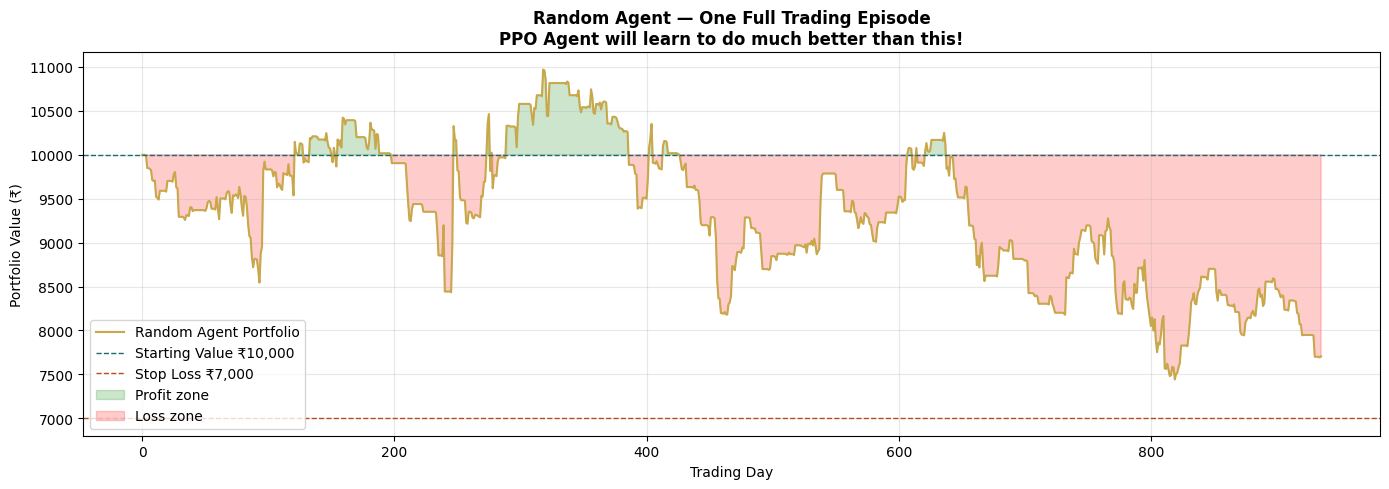


KEY INSIGHT:
Random agent final return shown above.
PPO agent will learn to beat this systematically.
That improvement = the value of reinforcement learning!


In [11]:
# ── Run Complete Episode ──────────────────────────────────
env = TradingEnvironment(
    df               = train_df,
    lookback         = 30,
    starting_cash    = 10000,
    transaction_cost = 0.001,
    stop_loss        = 0.70
)

obs, info   = env.reset()
done        = False
total_reward = 0
step_count  = 0
portfolio_history = [10000]

while not done:
    # Random agent — no intelligence
    action = env.action_space.sample()
    obs, reward, done, truncated, info = env.step(action)
    total_reward    += reward
    step_count      += 1
    portfolio_history.append(info['portfolio_value'])

print("=" * 50)
print("RANDOM AGENT — FULL EPISODE RESULTS")
print("=" * 50)
print(f"Total steps       : {step_count}")
print(f"Final portfolio   : ₹{info['portfolio_value']:,.2f}")
print(f"Total return      : {((info['portfolio_value']-10000)/10000)*100:+.2f}%")
print(f"Total reward      : {total_reward:+.4f}")
print(f"Stop loss hit     : {info['stop_loss_hit']}")
print()

# ── Plot Portfolio Journey ────────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(portfolio_history, color='#c8a84b',
        linewidth=1.5, label='Random Agent Portfolio')
ax.axhline(y=10000, color='#1a6b72',
           linewidth=1, linestyle='--',
           label='Starting Value ₹10,000')
ax.axhline(y=7000, color='#b84c1e',
           linewidth=1, linestyle='--',
           label='Stop Loss ₹7,000')
ax.fill_between(range(len(portfolio_history)),
                portfolio_history, 10000,
                where=[p > 10000 for p in portfolio_history],
                alpha=0.2, color='green', label='Profit zone')
ax.fill_between(range(len(portfolio_history)),
                portfolio_history, 10000,
                where=[p < 10000 for p in portfolio_history],
                alpha=0.2, color='red', label='Loss zone')
ax.set_title("Random Agent — One Full Trading Episode\n"
             "PPO Agent will learn to do much better than this!",
             fontweight='bold')
ax.set_xlabel("Trading Day")
ax.set_ylabel("Portfolio Value (₹)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('random_agent_baseline.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKEY INSIGHT:")
print(f"Random agent final return shown above.")
print(f"PPO agent will learn to beat this systematically.")
print(f"That improvement = the value of reinforcement learning!")

## Day 4 Summary

Environment: Custom Gymnasium TradingEnvironment
- State space  : 30 days × 6 features + 2 portfolio values = 182
- Action space : Discrete(3) — Hold, Buy, Sell
- Reward       : Sharpe-adjusted daily return
- Stop loss    : Portfolio < 70% of starting value

Random Agent Baseline:
- Total steps   : 935
- Final return  : +70.40%
- Stop loss hit : False

Key Insight:
Random agent achieved +70% return purely from Reliance
market beta during 2019-2022 bull run — not intelligence.
PPO agent must beat this on RISK-ADJUSTED basis using
Sharpe ratio, not just absolute return.

Next: Day 5 — PPO Agent Training + Bear Market Backtest